In [11]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image

import sys
PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
SRC_DIR = str(PROJECT_DIR / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

GROUND_TRUTH_DIR = PROJECT_DIR / "data" / "ground_truth_files"

In [ ]:
def load_ground_truth(ground_truth_file):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    "Macrophage": {
        # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
    },
    # "mESC": {
    #     "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
    #     "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
    #     "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
    #     "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
    #     "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    # },
    # "K562": {
    #     "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
    #     "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    # },
    # "iPSC": {
    #     # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
    #     "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
    #     # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    # }
}

In [129]:
def calculate_auroc_all_sample_gts(df, ground_truth_dict):    
    pooled_auroc = []
    per_tf_auroc = []
    for gt_name, ground_truth in ground_truth_dict.items():
        _, gt_lookup = ground_truth
        
        labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, gt_name)
        
        gt_pooled_auroc = exp.quick_pooled_auroc(labeled_df)
        gt_per_tf_auroc = exp.quick_per_tf_auroc(labeled_df)
        
        pooled_auroc.append(gt_pooled_auroc)
        per_tf_auroc.append(gt_per_tf_auroc)

    pooled_median_auroc = np.median(pooled_auroc)
    per_tf_median_auroc = np.median(per_tf_auroc)
        
    auroc_df = pd.DataFrame({
        "pooled_median_auroc": pooled_median_auroc,
        "per_tf_median_auroc": per_tf_median_auroc,
    }, index=[0])
    
    return auroc_df

In [2]:
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

cell_type="Macrophage"
sample_name="buffer_1"
experiment_name=f"{cell_type}_{sample_name}_tutorial"
organism_code="hg38"

exp = experiment_handler.load_experiment_handler(
    tdf_settings_path=DATA_DIR / "PROCESSED_DATA" / experiment_name / "settings.json",
    experiment_dir=DATA_DIR / "EXPERIMENTS/",
    model_num=1,
)

Macrophage_buffer_1_tutorial: Loaded existing settings
Loading ExperimentHandler state from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/Macrophage_buffer_1_tutorial/model_training_001/experiment_handler_save.json...


In [141]:
atac_grn = exp.load_atac_grn()
atac_grn["Source"] = atac_grn["Source"].str.lower()
atac_grn.rename(columns={"Source": "peak_id"}, inplace=True)

tf_tg_grn = exp.load_grn()

In [5]:
homer_tf_to_peak_df = pd.read_parquet(
    PROJECT_DIR / "dev" / "Homer" / "homer_tf_to_peak.parquet"
)
homer_tf_to_peak_df.rename(columns={"source_id": "Source"}, inplace=True)
homer_tf_to_peak_df[["Source", "peak_id", "homer_binding_score"]]
homer_tf_to_peak_df["Source"] = homer_tf_to_peak_df["Source"].str.upper()

In [6]:
peak_tg_dist_df = pd.read_parquet(exp.tdf.file_paths["samples"][sample_name]["peak_to_gene_dist"])
peak_tg_dist_df = peak_tg_dist_df[["peak_id", "target_id", "TSS_dist"]].rename(columns={"target_id": "Target"})
peak_tg_dist_df.head()

,peak_id,Target,TSS_dist
0,chr2:219217662-219218426,ABCB6,0
1,chr16:30355035-30355887,CD2BP2-DT,0
2,chr12:6605965-6606682,CHD4,0
3,chr4:1243446-1244560,CTBP1,0
4,chr15:44426818-44427642,CTDSPL2,0


In [142]:
def print_dataframes_info(df, name):
    print(f"{name} DataFrame:")
    display(df.head())
    if 'peak_id' in df.columns:
        print(f"Number of unique peaks: {df['peak_id'].nunique()}")
    if 'Source' in df.columns:
        print(f"Number of unique sources: {df['Source'].nunique()}")
    if 'Target' in df.columns:
        print(f"Number of unique targets: {df['Target'].nunique()}")
    print(f"Number of rows: {len(df)}")
    print("-" * 40)

print_dataframes_info(atac_grn, "ATAC GRN")
print_dataframes_info(homer_tf_to_peak_df, "Homer TF-to-Peak")
print_dataframes_info(tf_tg_grn, "TF-TG GRN")
print_dataframes_info(peak_tg_dist_df, "Peak-TG Distance")

ATAC GRN DataFrame:


,peak_id,Target,Score
0,chr1:923373-924275,A3GALT2,0.354727
1,chr1:923373-924275,ABCB10,-0.252396
2,chr1:923373-924275,ABCD3,-0.510703
3,chr1:923373-924275,ABL2,1.044350
4,chr1:923373-924275,ACADM,0.538197


Number of unique peaks: 63385
Number of unique targets: 12549
Number of rows: 43112114
----------------------------------------
Homer TF-to-Peak DataFrame:


,peak_id,Source,homer_binding_score
0,chr7:74964093-74964967,PKNOX1,0.000104
1,chr8:80934135-80935019,PKNOX1,0.000104
2,chr8:54048421-54049295,PKNOX1,0.000104
3,chr14:88305223-88306109,PKNOX1,0.000104
4,chr1:167661291-167662242,PKNOX1,0.000104


Number of unique peaks: 121975
Number of unique sources: 278
Number of rows: 9236247
----------------------------------------
TF-TG GRN DataFrame:


,Source,Target,Score
0,AC092835,A1BG,0.379014
1,AC092835,A2M,0.389120
2,AC092835,A2ML1,-0.737082
3,AC092835,A3GALT2,-0.694372
4,AC092835,A4GALT,-0.571215


Number of unique sources: 1177
Number of unique targets: 12549
Number of rows: 14770173
----------------------------------------
Peak-TG Distance DataFrame:


,peak_id,Target,TSS_dist
0,chr2:219217662-219218426,ABCB6,0
1,chr16:30355035-30355887,CD2BP2-DT,0
2,chr12:6605965-6606682,CHD4,0
3,chr4:1243446-1244560,CTBP1,0
4,chr15:44426818-44427642,CTDSPL2,0


Number of unique peaks: 118118
Number of unique targets: 27222
Number of rows: 118118
----------------------------------------


In [139]:
shared_peaks = set(homer_tf_to_peak_df["peak_id"]).intersection(set(atac_grn["peak_id"]))
print(f"Number of shared peaks: {len(shared_peaks)}")
print(f"Total peaks in Homer TF-to-Peak: {len(homer_tf_to_peak_df)}")
print(f"Total peaks in ATAC GRN: {len(atac_grn)}")

Number of shared peaks: 63385
Total peaks in Homer TF-to-Peak: 9236247
Total peaks in ATAC GRN: 63385


In [ ]:
merge_by_peak = homer_tf_to_peak_df.merge(atac_grn, on="peak_id", how="outer").rename(columns={"Score": "atac_tg_grad_score"})
merged_df = tf_tg_grn.merge(merge_by_peak, on=["Source", "Target"], how="inner").rename(columns={"Score": "tf_tg_grad_score"})

merged_df = merged_df[["Source", "peak_id", "Target", "tf_tg_grad_score", "atac_tg_grad_score", "homer_binding_score"]]

display(merged_df.head())
print(f"TFs: {merged_df['Source'].nunique()}")
print(f"TG: {merged_df['Target'].nunique()}")
print(f"Edges: {len(merged_df[['Source', 'Target']].drop_duplicates())}")

In [ ]:
len(merge_by_peak)

9236247

In [ ]:
len(merged_df)

2179937

Sources with most edges:
0: NANOG (55177 edges)
1: TGIF2 (49998 edges)
2: TGIF1 (47846 edges)
3: SMAD3 (45894 edges)
4: ERG (40486 edges)
5: HIC1 (40175 edges)
6: NFATC2 (39432 edges)
7: FOXO1 (37951 edges)
8: ZBTB9 (37930 edges)
9: ETV1 (37214 edges)
Source: ETV1


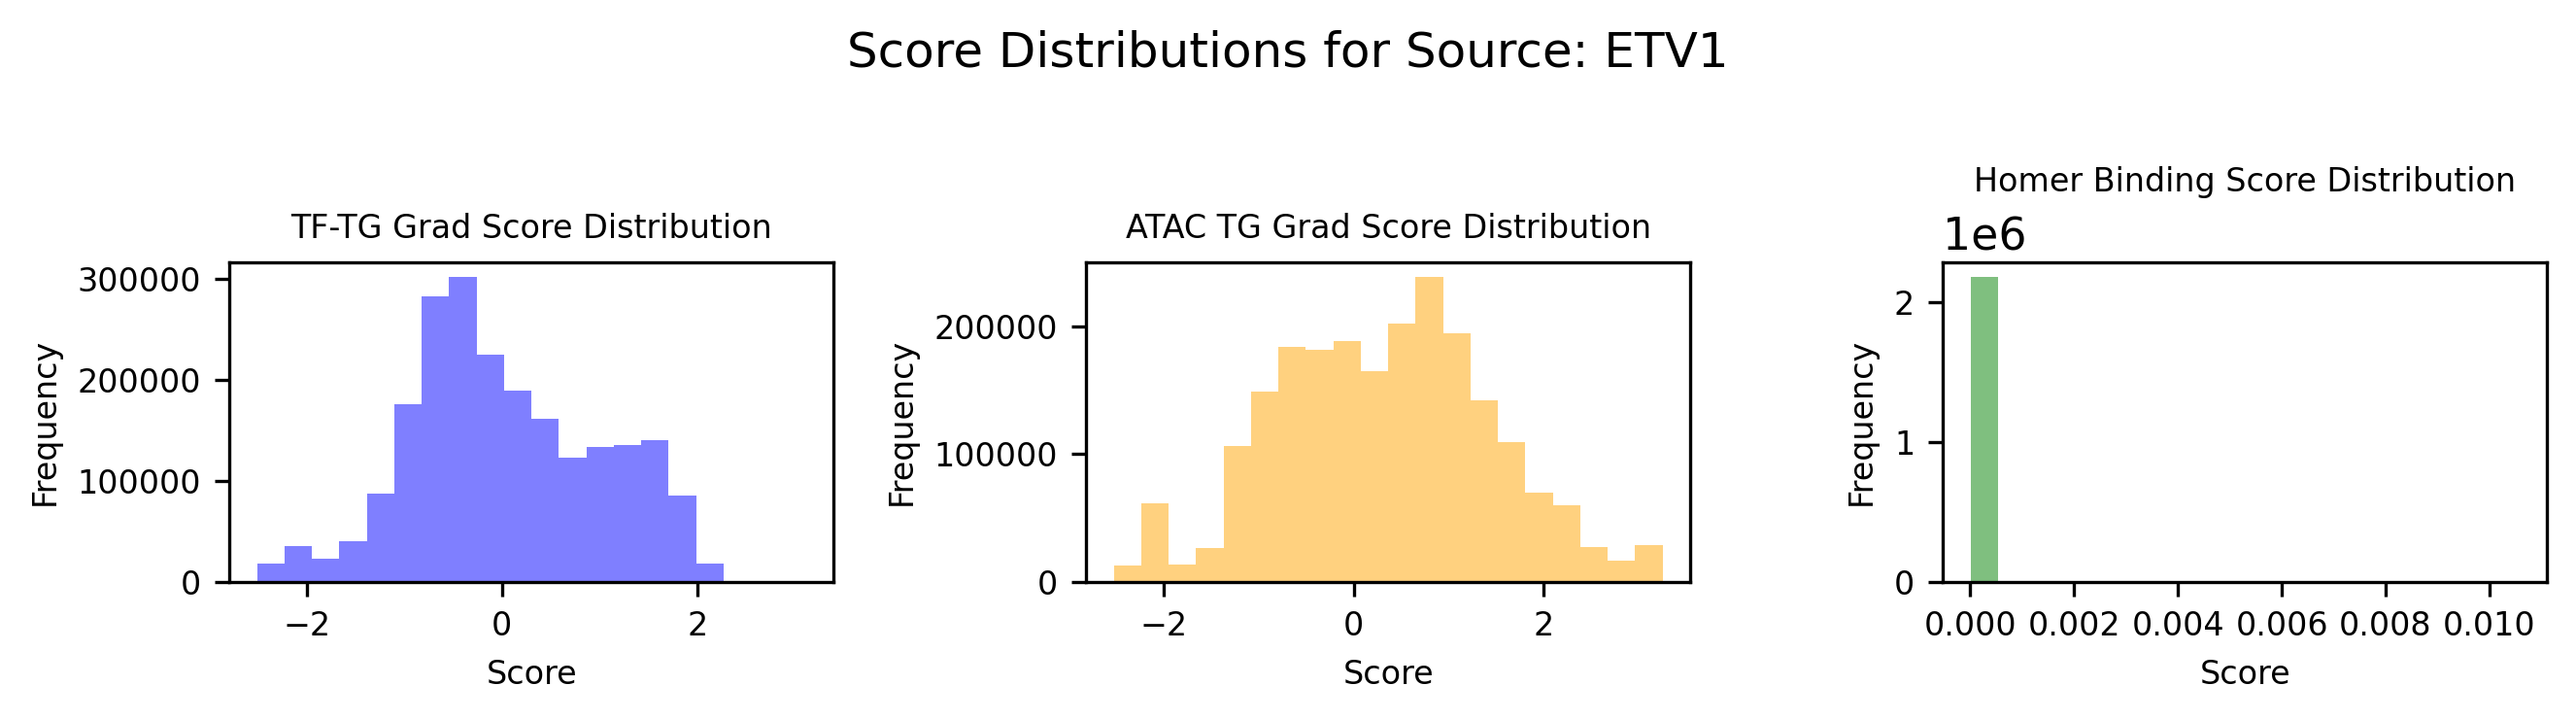

In [ ]:
source_num = 0

source_counts = merged_df["Source"].value_counts()
tf_most_edges = source_counts.index.tolist()

print("Sources with most edges:")
for i, source in enumerate(tf_most_edges[:10]):
    print(f"{i}: {source} ({source_counts[source]} edges)")

edge_df = merged_df.copy()

print(f"Source: {source}")

fig, ax = plt.subplots(1, 3, figsize=(9, 2.5))
ax[0].hist(edge_df["tf_tg_grad_score"], bins=20, alpha=0.5, label="TF-TG Grad Score", color="blue")
ax[0].set_title("TF-TG Grad Score Distribution", fontsize=8)
ax[0].set_xlabel("Score", fontsize=8)
ax[0].set_ylabel("Frequency", fontsize=8)
ax[0].tick_params(axis='both', which='major', labelsize=8)

ax[1].hist(edge_df["atac_tg_grad_score"], bins=20, alpha=0.5, label="ATAC TG Grad Score", color="orange")
ax[1].set_title("ATAC TG Grad Score Distribution", fontsize=8)
ax[1].set_xlabel("Score", fontsize=8)
ax[1].set_ylabel("Frequency", fontsize=8)
ax[1].tick_params(axis='both', which='major', labelsize=8)

ax[2].hist(edge_df["homer_binding_score"], bins=20, alpha=0.5, label="Homer Binding Score", color="green")
ax[2].set_title("Homer Binding Score Distribution", fontsize=8)
ax[2].set_xlabel("Score", fontsize=8)
ax[2].set_ylabel("Frequency", fontsize=8)
ax[2].tick_params(axis='both', which='major', labelsize=8)

plt.suptitle(f"Score Distributions for Source: {source}", fontsize=12)
plt.tight_layout()
fig.show()

In [123]:
grn_df = edge_df.groupby(["Source", "Target"]).agg({
    "tf_tg_grad_score": "mean",
    "atac_tg_grad_score": "mean",
    "homer_binding_score": "mean"
}).reset_index()

def normalize_scores(score_series):
    min_score = score_series.min()
    max_score = score_series.max()
    if max_score > min_score:
        return (score_series - min_score) / (max_score - min_score)
    else:
        return pd.Series(1.0, index=score_series.index)

score_cols = [
    "tf_tg_grad_score",
    "atac_tg_grad_score",
    "homer_binding_score",
]

for col in score_cols:
    grn_df[f"{col}_norm"] = normalize_scores(grn_df[col])

eps = 1e-6

grn_df["Score"] = (
    grn_df["tf_tg_grad_score_norm"].clip(lower=eps)
    * grn_df["atac_tg_grad_score_norm"].clip(lower=eps)
    * grn_df["homer_binding_score_norm"].clip(lower=eps)
)

grn_df = grn_df[["Source", "Target", "Score"]].sort_values(by="Score", ascending=False).reset_index(drop=True)

grn_df.head()

,Source,Target,Score
0,ZNF528,ABCA1,0.585227
1,ZNF528,ABCC5,0.507048
2,ZNF528,AAK1,0.498074
3,ZNF528,AAGAB,0.364135
4,ZNF528,A2M,0.328608


In [ ]:
print("GRN edges:", len(grn_df))
print("GRN TFs:", grn_df["Source"].nunique())
print("GRN targets:", grn_df["Target"].nunique())

for gt_name, ground_truth in gt_by_dataset_dict[cell_type].items():
    gt_df, gt_lookup = ground_truth
    gt_tfs, gt_targets, gt_pairs = gt_lookup

    grn_tfs = set(grn_df["Source"].astype(str).str.upper())
    grn_targets = set(grn_df["Target"].astype(str).str.upper())

    print()
    print(gt_name)
    print("  overlapping TFs:", len(grn_tfs & gt_tfs))
    print("  overlapping targets:", len(grn_targets & gt_targets))

auroc_df = calculate_auroc_all_sample_gts(grn_df, gt_by_dataset_dict["Macrophage"])

pooled_median_auroc = auroc_df["pooled_median_auroc"].iloc[0]
per_tf_median_auroc = auroc_df["per_tf_median_auroc"].iloc[0]
print(f"Pooled Median AUROC: {pooled_median_auroc:.4f}")
print(f"Per-TF Median AUROC: {per_tf_median_auroc:.4f}")

GRN edges: 2750
GRN TFs: 125
GRN targets: 22

ChIP-Atlas macrophage
  overlapping TFs: 5
  overlapping targets: 21
